In [16]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
client = bigquery.Client(project='ga4-funnel-analysis-509819')
print('Connected!')

Connected!


In [17]:
funnel_sql = """
SELECT
  COUNT(DISTINCT user_pseudo_id) AS visitors,
  COUNT(DISTINCT IF(event_name = 'view_item', user_pseudo_id, NULL)) AS viewed_product,
  COUNT(DISTINCT IF(event_name = 'add_to_cart', user_pseudo_id, NULL)) AS added_to_cart,
  COUNT(DISTINCT IF(event_name = 'begin_checkout', user_pseudo_id, NULL)) AS began_checkout,
  COUNT(DISTINCT IF(event_name = 'purchase', user_pseudo_id, NULL)) AS purchased
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20210131'
"""
funnel = client.query(funnel_sql).to_dataframe()
funnel

,visitors,viewed_product,added_to_cart,began_checkout,purchased
0,270154,61252,12545,9715,4419


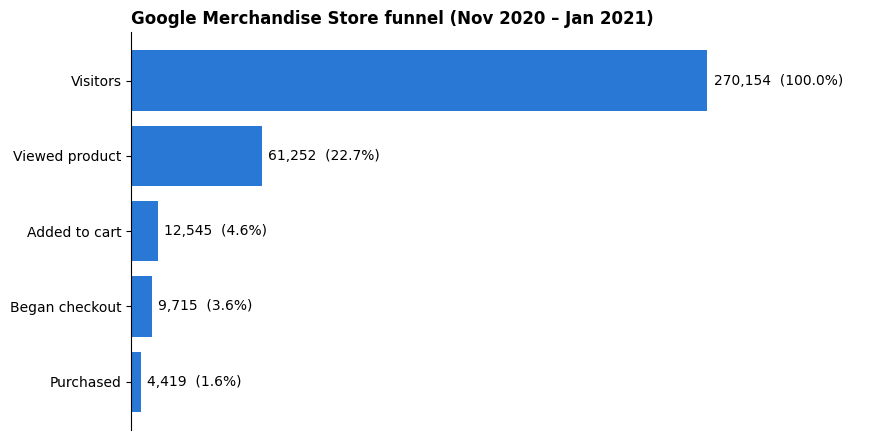

In [18]:
import matplotlib.pyplot as plt

steps = ['Visitors', 'Viewed product', 'Added to cart', 'Began checkout', 'Purchased']
values = funnel.iloc[0].tolist()

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(steps[::-1], values[::-1], color='#2a78d6')
for bar, v in zip(bars, values[::-1]):
    ax.text(bar.get_width() + 3000, bar.get_y() + bar.get_height() / 2,
            f'{v:,}  ({v / values[0]:.1%})', va='center', fontsize=10)

ax.set_title('Google Merchandise Store funnel (Nov 2020 – Jan 2021)',
             loc='left', fontweight='bold')
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xticks([])
ax.set_xlim(0, values[0] * 1.3)
plt.tight_layout()
plt.savefig('funnel.png', dpi=200)
plt.show()

In [19]:
channel_sql = """
SELECT
  CASE
    WHEN traffic_source.medium = 'referral'
         AND traffic_source.source LIKE '%googlemerchandisestore%' THEN 'referral (self)'
    WHEN traffic_source.medium = 'referral' THEN 'referral (external)'
    WHEN traffic_source.medium = '(none)' THEN 'direct'
    WHEN traffic_source.medium = 'cpc' THEN 'paid search (cpc)'
    ELSE traffic_source.medium
  END AS channel,
  COUNT(DISTINCT user_pseudo_id) AS visitors,
  COUNT(DISTINCT IF(event_name = 'purchase', user_pseudo_id, NULL)) AS purchased
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20210131'
  AND traffic_source.medium NOT IN ('<Other>', '(data deleted)')
GROUP BY channel
"""
channels = client.query(channel_sql).to_dataframe()
channels['conversion_rate'] = channels['purchased'] / channels['visitors'] * 100
channels = channels.sort_values('conversion_rate')
channels

,channel,visitors,purchased,conversion_rate
2,paid search (cpc),15528,152,0.978877
0,organic,112358,1323,1.177486
1,direct,75951,1054,1.387737
4,referral (external),32883,468,1.423228
3,referral (self),26065,568,2.179167


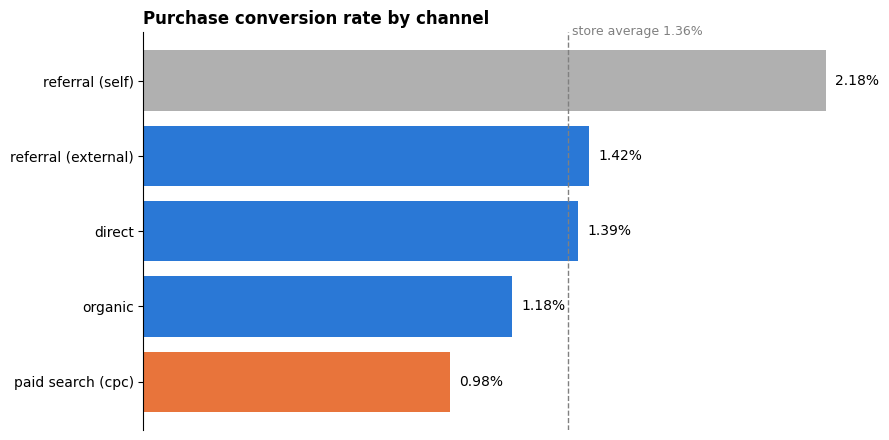

In [20]:
colors = ['#e8743b' if c == 'paid search (cpc)' else '#b0b0b0' if c == 'referral (self)' else '#2a78d6' for c in channels['channel']]
overall = channels['purchased'].sum() / channels['visitors'].sum() * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(channels['channel'], channels['conversion_rate'], color=colors)
for bar, v in zip(bars, channels['conversion_rate']):
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height() / 2,
            f'{v:.2f}%', va='center', fontsize=10)

ax.axvline(overall, color='grey', linestyle='--', linewidth=1)
ax.text(overall, len(channels) - 0.4, f' store average {overall:.2f}%', color='grey', fontsize=9)

ax.set_title('Purchase conversion rate by channel', loc='left', fontweight='bold')
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xticks([])
plt.tight_layout()
plt.savefig('channels.png', dpi=200)
plt.show()

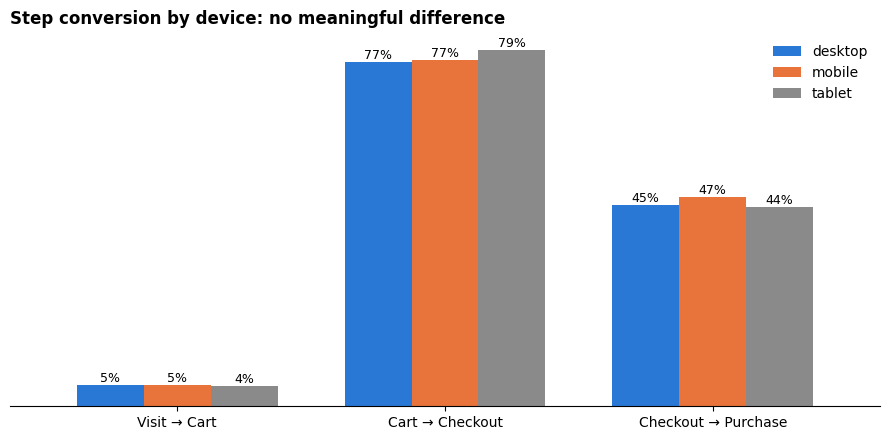

In [22]:
import pandas as pd
device_sql = """
SELECT
  device.category AS device,
  COUNT(DISTINCT user_pseudo_id) AS visitors,
  COUNT(DISTINCT IF(event_name = 'add_to_cart', user_pseudo_id, NULL)) AS added_to_cart,
  COUNT(DISTINCT IF(event_name = 'begin_checkout', user_pseudo_id, NULL)) AS began_checkout,
  COUNT(DISTINCT IF(event_name = 'purchase', user_pseudo_id, NULL)) AS purchased
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20210131'
GROUP BY device
"""
devices = client.query(device_sql).to_dataframe().set_index('device')

rates = pd.DataFrame({
    'Visit → Cart': devices['added_to_cart'] / devices['visitors'] * 100,
    'Cart → Checkout': devices['began_checkout'] / devices['added_to_cart'] * 100,
    'Checkout → Purchase': devices['purchased'] / devices['began_checkout'] * 100,
}).loc[['desktop', 'mobile', 'tablet']]

ax = rates.T.plot(kind='bar', figsize=(9, 4.5), color=['#2a78d6', '#e8743b', '#8a8a8a'], width=0.75)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', fontsize=9)

ax.set_title('Step conversion by device: no meaningful difference', loc='left', fontweight='bold')
ax.set_xticklabels(rates.columns, rotation=0)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.set_yticks([])
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('devices.png', dpi=200)
plt.show()